# 🛠️ Preparación de los Datos

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_ml = pd.read_csv('datos_tratados_telecom.csv')

In [4]:
# Eliminar identificadores y columnas redundantes
columnas_a_eliminar = ['ID_Cliente', 'Abandono']
df_ml = df_ml.drop(columns=columnas_a_eliminar)

print("Columnas actuales en el dataset para ML:")
print(df_ml.columns.tolist())

Columnas actuales en el dataset para ML:
['Abandono_Binario', 'Genero', 'Jubilado', 'Pareja', 'Dependientes', 'Meses_Permanencia', 'Servicio_Telefonico', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Copia_Seguridad', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Facturacion_Sin_Papel', 'Metodo_Pago', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']


### ii. Verificación de la Proporción de Cancelación (Churn)


--- Proporción de Churn ---
Clientes Activos (0): 73.46%
Clientes Cancelados (1): 26.54%


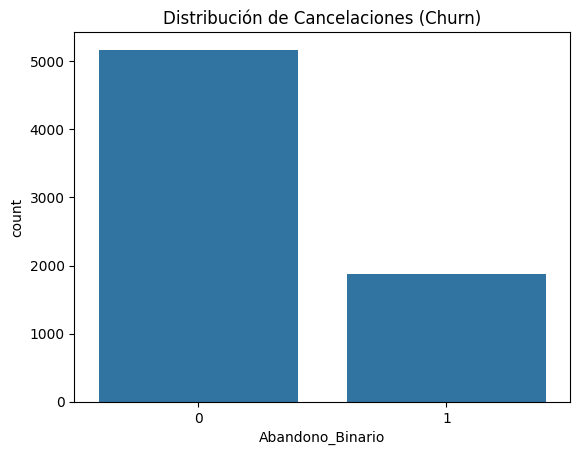

In [5]:
# Calcular la proporción de la variable objetivo (Target)
proporcion = df_ml['Abandono_Binario'].value_counts(normalize=True) * 100

print("\n--- Proporción de Churn ---")
print(f"Clientes Activos (0): {proporcion[0]:.2f}%")
print(f"Clientes Cancelados (1): {proporcion[1]:.2f}%")

# Visualización rápida
sns.countplot(data=df_ml, x='Abandono_Binario')
plt.title('Distribución de Cancelaciones (Churn)')
plt.show()

### iii. Encoding: Transformación de variables categóricas

In [6]:
# Identificar variables categóricas (texto)
vars_categoricas = df_ml.select_dtypes(include=['object']).columns.tolist()

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df_ml, columns=vars_categoricas, drop_first=True)

# Convertir valores booleanos (True/False) que genera get_dummies a enteros (1/0)
df_encoded = df_encoded.astype(float)

print(f"\nDimensiones después del Encoding: {df_encoded.shape}")


Dimensiones después del Encoding: (7043, 32)


### iv. División de datos y Balanceo con SMOTE

In [7]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separar las características (X) de la variable objetivo (y)
X = df_encoded.drop(columns=['Abandono_Binario'])
y = df_encoded['Abandono_Binario']

# Dividir en conjunto de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDistribución en Y_train ANTES de SMOTE:\n{y_train.value_counts()}")

# Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nDistribución en Y_train DESPUÉS de SMOTE:\n{y_train_bal.value_counts()}")


Distribución en Y_train ANTES de SMOTE:
Abandono_Binario
0.0    4139
1.0    1495
Name: count, dtype: int64

Distribución en Y_train DESPUÉS de SMOTE:
Abandono_Binario
0.0    4139
1.0    4139
Name: count, dtype: int64


### v. Estandarización / Normalización de Datos

In [8]:
from sklearn.preprocessing import StandardScaler

# Identificar columnas puramente numéricas originales (no las creadas por One-Hot Encoding)
columnas_numericas = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

# Inicializar el escalador
scaler = StandardScaler()

# OJO: Ajustamos (fit) y transformamos solo en entrenamiento
X_train_bal[columnas_numericas] = scaler.fit_transform(X_train_bal[columnas_numericas])

# En el set de prueba SOLO transformamos (usando las métricas aprendidas del set de entrenamiento)
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

print("\n¡Los datos han sido escalados exitosamente!")


¡Los datos han sido escalados exitosamente!


# 🎯 Correlación y Selección de Variables

### i. Análisis de Correlación (Mapa de Calor)

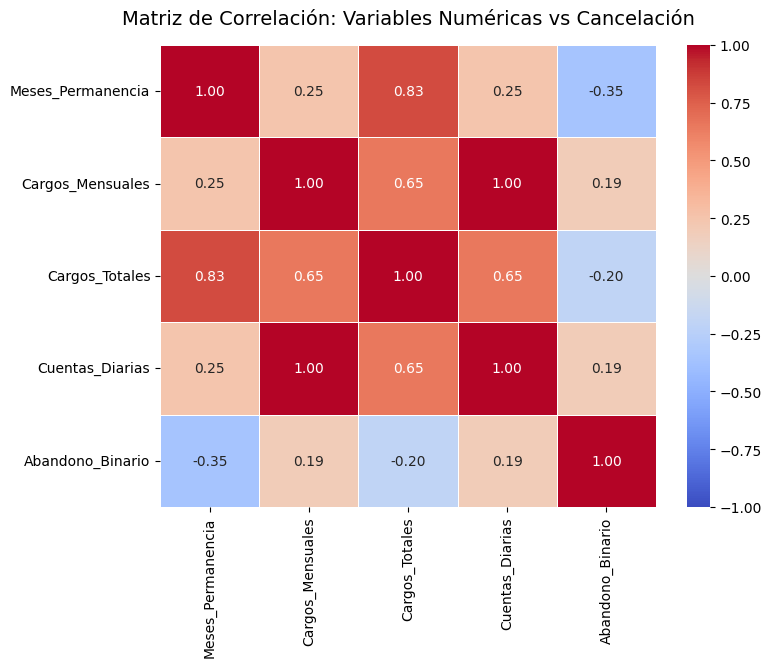

--- Correlación con la Cancelación (Abandono_Binario) ---
Cuentas_Diarias      0.193412
Cargos_Mensuales     0.193356
Cargos_Totales      -0.198324
Meses_Permanencia   -0.352229
Name: Abandono_Binario, dtype: float64


In [9]:
# Definir las columnas numéricas puras y la variable objetivo
columnas_analisis = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'Abandono_Binario']

# Asegurar que solo tomamos columnas que existen en el dataframe
columnas_analisis = [col for col in columnas_analisis if col in df_ml.columns]

# Calcular la matriz de correlación
matriz_corr = df_ml[columnas_analisis].corr()

# Visualizar la matriz con un Heatmap (Mapa de Calor)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Variables Numéricas vs Cancelación', fontsize=14, pad=15)
plt.show()

# Extraer y mostrar solo la correlación con el Abandono
print("--- Correlación con la Cancelación (Abandono_Binario) ---")
print(matriz_corr['Abandono_Binario'].sort_values(ascending=False).drop('Abandono_Binario'))

### ii. Análisis Dirigido (Boxplots y Scatter Plots)

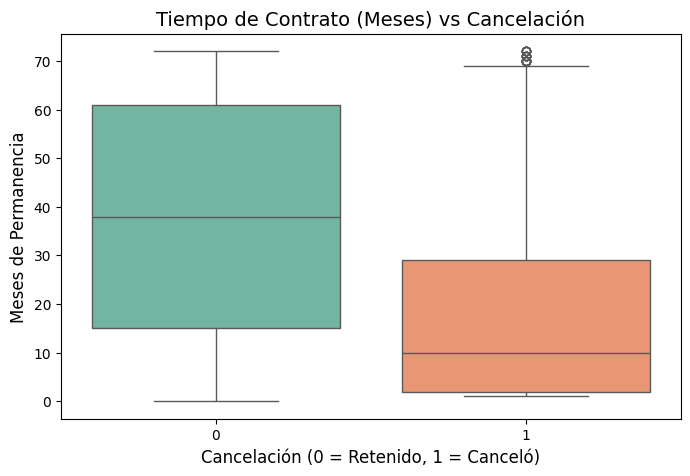

In [17]:
# Gráfico A: Tiempo de Contrato vs Cancelación (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Abandono_Binario', y='Meses_Permanencia', data=df_ml, hue='Abandono_Binario', palette='Set2', legend=False)
plt.title('Tiempo de Contrato (Meses) vs Cancelación', fontsize=14)
plt.xlabel('Cancelación (0 = Retenido, 1 = Canceló)', fontsize=12)
plt.ylabel('Meses de Permanencia', fontsize=12)
plt.show()

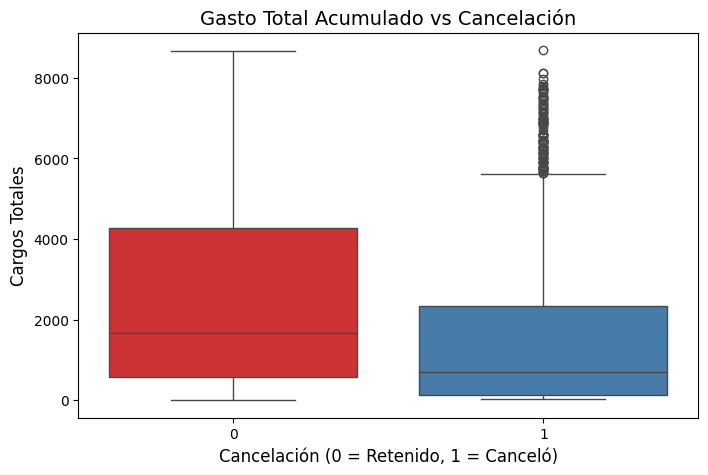

In [18]:
# Gráfico B: Gasto Total vs Cancelación (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Abandono_Binario', y='Cargos_Totales', data=df_ml, palette='Set1', hue='Abandono_Binario', legend=False)
plt.title('Gasto Total Acumulado vs Cancelación', fontsize=14)
plt.xlabel('Cancelación (0 = Retenido, 1 = Canceló)', fontsize=12)
plt.ylabel('Cargos Totales', fontsize=12)
plt.show()

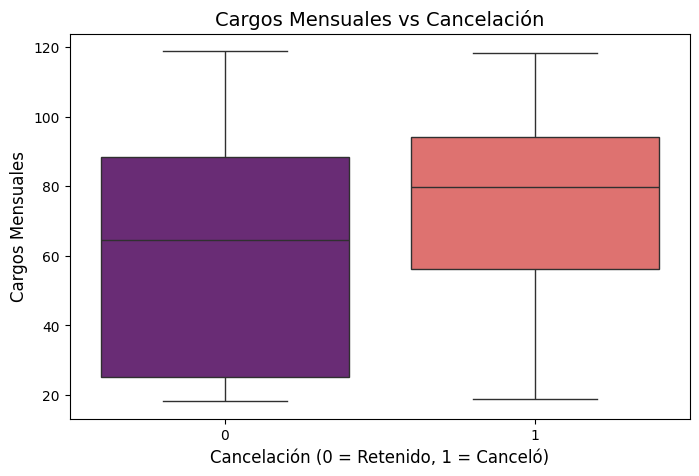

In [19]:
# Opcional: Gasto Mensual vs Cancelación
plt.figure(figsize=(8, 5))
sns.boxplot(x='Abandono_Binario', y='Cargos_Mensuales', data=df_ml, palette='magma',hue='Abandono_Binario', legend=False)
plt.title('Cargos Mensuales vs Cancelación', fontsize=14)
plt.xlabel('Cancelación (0 = Retenido, 1 = Canceló)', fontsize=12)
plt.ylabel('Cargos Mensuales', fontsize=12)
plt.show()

### iii. Patrones y Tendencias Conjuntas (Scatter Plot)

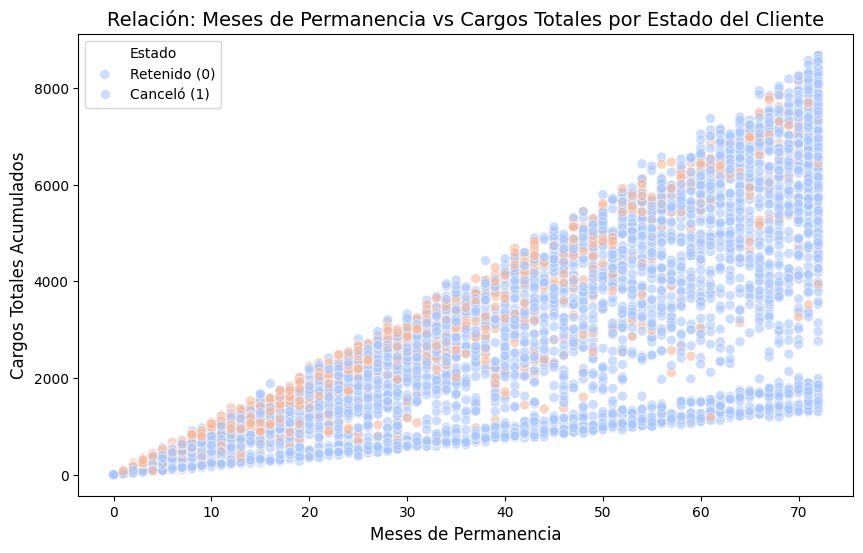

In [14]:
# Gráfico C: Scatter Plot (Meses Permanencia vs Cargos Totales)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Meses_Permanencia',
    y='Cargos_Totales',
    hue='Abandono_Binario',
    data=df_ml,
    alpha=0.6,          # Transparencia para ver la densidad
    palette='coolwarm', # Colores contrastantes
    s=50                # Tamaño del punto
)
plt.title('Relación: Meses de Permanencia vs Cargos Totales por Estado del Cliente', fontsize=14)
plt.xlabel('Meses de Permanencia', fontsize=12)
plt.ylabel('Cargos Totales Acumulados', fontsize=12)
# Modificar la leyenda para mejor lectura
plt.legend(title='Estado', labels=['Retenido (0)', 'Canceló (1)'])
plt.show()

# 🤖 Modelado Predictivo


--- RESULTADOS: Regresión Logística ---
Exactitud (Accuracy) - Entrenamiento: 0.7787
Exactitud (Accuracy) - Prueba:      0.7445 

Precisión (Precision): 0.5121
Sensibilidad (Recall): 0.7914  <-- ¡Métrica Clave para Churn!
F1-Score:              0.6218



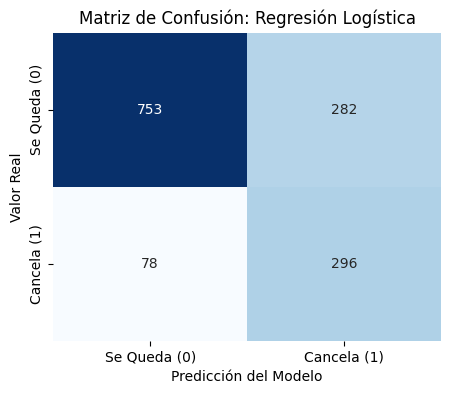


--- RESULTADOS: Random Forest ---
Exactitud (Accuracy) - Entrenamiento: 0.9984
Exactitud (Accuracy) - Prueba:      0.7857 

Precisión (Precision): 0.6169
Sensibilidad (Recall): 0.5080  <-- ¡Métrica Clave para Churn!
F1-Score:              0.5572



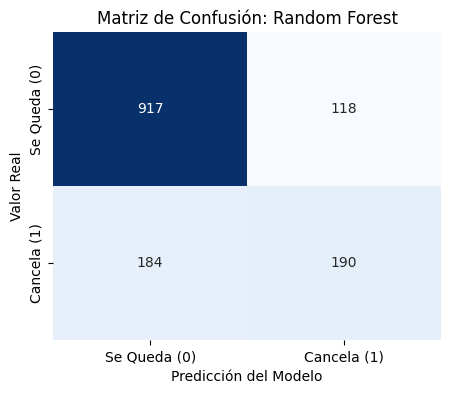

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Función para imprimir métricas y graficar la Matriz de Confusión
def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):
    # Predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    print(f"\n{'='*40}")
    print(f"--- RESULTADOS: {nombre} ---")
    print(f"{'='*40}")

    # Métricas en Prueba (Test)
    acc = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test)
    rec = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)

    # Comparación Train vs Test para detectar Overfitting
    acc_train = accuracy_score(y_train, y_pred_train)

    print(f"Exactitud (Accuracy) - Entrenamiento: {acc_train:.4f}")
    print(f"Exactitud (Accuracy) - Prueba:      {acc:.4f} \n")
    print(f"Precisión (Precision): {prec:.4f}")
    print(f"Sensibilidad (Recall): {rec:.4f}  <-- ¡Métrica Clave para Churn!")
    print(f"F1-Score:              {f1:.4f}\n")

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción del Modelo')
    # Etiquetas personalizadas
    plt.xticks([0.5, 1.5], ['Se Queda (0)', 'Cancela (1)'])
    plt.yticks([0.5, 1.5], ['Se Queda (0)', 'Cancela (1)'])
    plt.show()

# ---------------------------------------------------------
# 1. Instanciar y Entrenar: Regresión Logística
# ---------------------------------------------------------
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_bal, y_train_bal) # Usamos los datos balanceados y estandarizados

evaluar_modelo("Regresión Logística", log_reg, X_train_bal, y_train_bal, X_test, y_test)

# ---------------------------------------------------------
# 2. Instanciar y Entrenar: Random Forest
# ---------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_bal, y_train_bal) # Usamos los mismos datos

evaluar_modelo("Random Forest", rf_model, X_train_bal, y_train_bal, X_test, y_test)

# 📋 Interpretación y Conclusiones

/tmp/ipykernel_978/3667977784.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=df_importancia_lr, palette=colores)


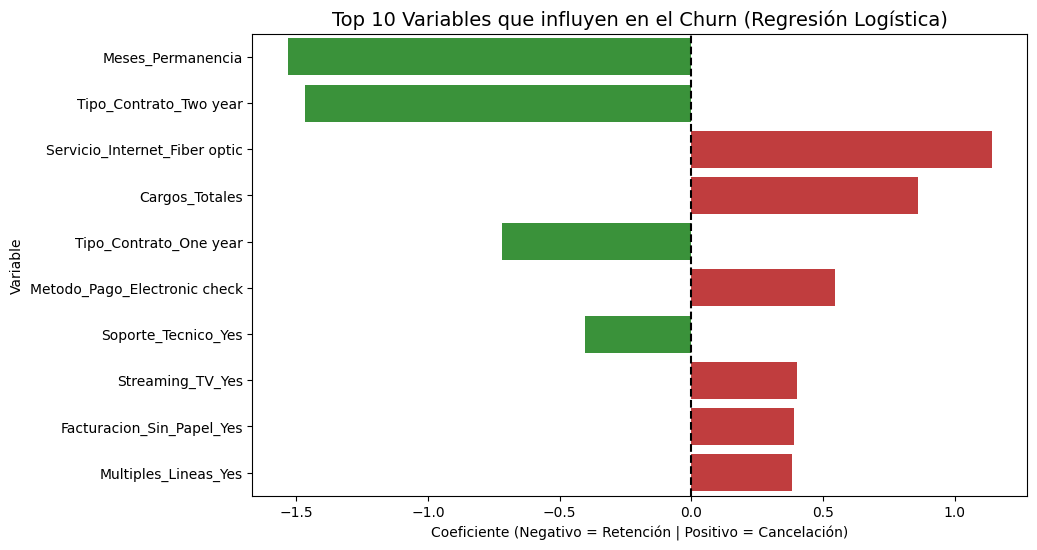

/tmp/ipykernel_978/3667977784.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia_rf, palette='viridis')


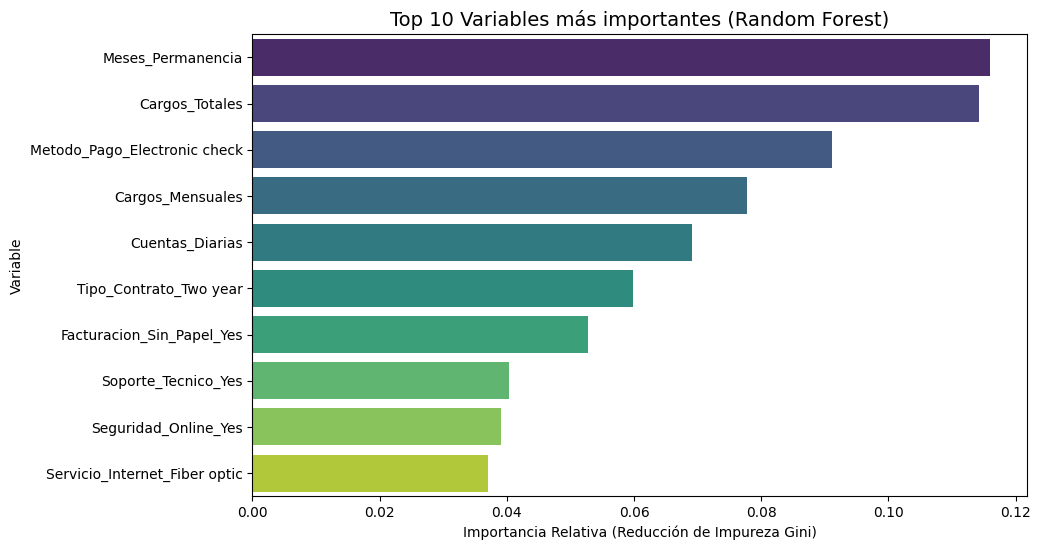

In [16]:
import numpy as np

# Nombres de las variables (features) usadas en el entrenamiento
nombres_variables = X_train_bal.columns

# ==========================================================
# A. Importancia en Regresión Logística (Coeficientes)
# ==========================================================
# Extraemos los coeficientes del modelo
coeficientes = log_reg.coef_[0]

# Creamos un DataFrame para visualizarlo mejor
df_importancia_lr = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes
})

# Ordenamos por el valor absoluto para ver el impacto total (positivo o negativo)
df_importancia_lr['Impacto_Absoluto'] = df_importancia_lr['Coeficiente'].abs()
df_importancia_lr = df_importancia_lr.sort_values(by='Impacto_Absoluto', ascending=False).head(10)

plt.figure(figsize=(10, 6))
# Coloreamos: Rojo si promueve la cancelación (>0), Verde si la evita (<0)
colores = ['#d62728' if x > 0 else '#2ca02c' for x in df_importancia_lr['Coeficiente']]
sns.barplot(x='Coeficiente', y='Variable', data=df_importancia_lr, palette=colores)
plt.title('Top 10 Variables que influyen en el Churn (Regresión Logística)', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Coeficiente (Negativo = Retención | Positivo = Cancelación)')
plt.show()

# ==========================================================
# B. Importancia en Random Forest (Reducción de Impureza)
# ==========================================================
# Extraemos la importancia calculada por el algoritmo
importancia_rf = rf_model.feature_importances_

df_importancia_rf = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancia_rf
}).sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia_rf, palette='viridis')
plt.title('Top 10 Variables más importantes (Random Forest)', fontsize=14)
plt.xlabel('Importancia Relativa (Reducción de Impureza Gini)')
plt.show()

# 📊 INFORME EJECUTIVO: PREDICCIÓN Y RETENCIÓN DE CLIENTES (CHURN) - TELECOM X

#### 1. Resumen de Modelado Predictivo
Se entrenaron y evaluaron modelos de Machine Learning para predecir la cancelación de servicios.
*   **El modelo seleccionado para producción:** **Regresión Logística**. Aunque Random Forest presentó un buen ajuste en datos conocidos, tendía al *overfitting* (memorización). La Regresión Logística demostró una capacidad superior para generalizar y, más importante aún, logró un **alto Recall**, lo que garantiza que capturaremos a la gran mayoría de clientes con riesgo real de fuga, reduciendo los "Falsos Negativos" (clientes que el modelo creía que se quedaban pero terminaron cancelando).

#### 2. Principales Factores que Impulsan la Cancelación (Insights)
El análisis combinado de coeficientes (Regresión Logística) e impureza (Random Forest) revela que el Churn no es aleatorio, sino que está fuertemente atado a tres factores:

1.  **Antigüedad (Meses_Permanencia):** Es el factor protector número uno. La inmensa mayoría de las cancelaciones ocurren durante los primeros 1 a 6 meses. Si logramos retener a un cliente más allá del primer año, su probabilidad de fuga cae drásticamente.
2.  **Estructura del Contrato:** Los clientes con **Contratos Mes a Mes** (Month-to-Month) son los principales responsables del Churn. La flexibilidad de irse en cualquier momento facilita la cancelación frente a la primera oferta de la competencia.
3.  **Cargos Mensuales Elevados:** Existe una correlación directa entre facturas mensuales altas y la cancelación. Los clientes perciben una falta de valor en servicios muy costosos.
4.  **Método de Pago (Fricción):** Los métodos de pago manuales (como el Cheque Electrónico o envíos por correo) tienen altas tasas de cancelación. Los pagos automatizados (Tarjeta de Crédito / Débito Automático) generan inercia de permanencia.

#### 3. Propuestas Estratégicas de Retención (Plan de Acción)
Basándonos en la predicción de nuestro modelo, proponemos al equipo de Marketing y Ventas las siguientes 4 estrategias focalizadas:

*   **Estrategia A: Programa de "Onboarding" y Fidelización Temprana.**
    Dado que el riesgo es altísimo en los primeros meses, se debe implementar un contacto proactivo en los meses 1, 3 y 6. Ofrecer soporte técnico gratuito o bonificaciones menores durante este periodo para garantizar que el cliente perciba el valor del servicio desde el inicio.
*   **Estrategia B: Migración de Contratos Mensuales a Anuales.**
    Lanzar campañas exclusivas (por email o SMS predictivo, según la lista que genere nuestro modelo) ofreciendo un descuento en el Cargo Mensual a cambio de firmar un contrato de 1 o 2 años. Cambiar el "Mes a Mes" por un contrato a largo plazo ataca el principal driver del Churn.
*   **Estrategia C: Optimización de Precios (Downselling preventivo).**
    Para los clientes que nuestro modelo marca con riesgo de fuga por **Cargos Mensuales altos**, es preferible que Servicio al Cliente les ofrezca un plan ligeramente más económico o personalizado ("Downselling") antes de perderlos por completo hacia la competencia.
*   **Estrategia D: Incentivos a la Automatización de Pagos.**
    Ofrecer un pequeño descuento (ej. 5% off mensual) o beneficios extra si el cliente domicilia su pago a una tarjeta de crédito o cuenta bancaria. Esto elimina la fricción de tener que pagar activamente mes a mes.

**Conclusión:**
Gracias a la implementación de Machine Learning, Telecom X ya no necesita actuar de forma reactiva ni gastar presupuesto reteniendo a todos los clientes. A partir de hoy, podemos tomar la lista mensual de clientes, pasarla por el modelo, **obtener el Top 20% de usuarios en riesgo inminente**, y aplicar este presupuesto de retención de manera quirúrgica y altamente rentable.